# Designing a motion judge you can't fool

Red Light, Green Light needs one decision, made hundreds of times a match:
*did this player move?* It has to mean the same thing for a player at the
back of the room and one at the front, on a laptop pushing 60 frames a
second and a phone struggling at 12, with a crowd walking past in the
background.

This notebook walks through how the judge that ships was arrived at: three
designs that look reasonable until they are measured, the normalization that
fixes them, the sampling clock that fixes what normalization cannot, how the
cutoff was chosen, and what still fools the result.

Nothing here re-runs the benchmark. Every published figure is read from the
committed `reports/benchmark_results.json`, which
`redlight benchmark` writes in about two minutes and which reruns byte-identical
apart from its timings. A few small live experiments run on a synthetic scene,
where the exact displacement is known, and those are marked as such.

In [1]:
"""Setup: read the committed benchmark results, and make the engine importable."""

import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

REPO = next(
    p for p in [Path.cwd(), *Path.cwd().parents]
    if (p / "reports" / "benchmark_results.json").exists()
)
sys.path.insert(0, str(REPO / "src"))

RESULTS = json.loads((REPO / "reports" / "benchmark_results.json").read_text())
META = RESULTS["meta"]

# Two series carry almost every chart below: samples where somebody really
# moved, and their paired frozen twins. Fixed colours, assigned once, in the
# same order everywhere -- identity never depends on which chart you are in.
MOVING, FROZEN, PICKED = "#3b82f6", "#ef4444", "#f59e0b"
INK, MUTED = "#1f2933", "#6b7280"

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": MUTED,
    "axes.labelcolor": INK,
    "text.color": INK,
    "xtick.color": MUTED,
    "ytick.color": MUTED,
    "grid.color": "#e5e7eb",
    "font.size": 10,
})

print(f"footage      {META['video']}  {META['fps']:.0f} fps, {META['frames_used']} frames")
print(f"detector     {META['detector']} @ conf {META['detector_conf']}, seed {META['seed']}")
print(f"sampler      one pair every {META['sample_interval_s']} s -> {META['pairs_sampled']} pairs")
print(f"samples      {META['n_moving']} moving, {META['n_frozen']} frozen (paired one-for-one)")

footage      data/vtest.avi  10 fps, 795 frames
detector     yolo @ conf 0.35, seed 1729
sampler      one pair every 0.1 s -> 794 pairs
samples      4410 moving, 4410 frozen (paired one-for-one)


## The ground truth

The footage is 795 frames of pedestrians crossing a courtyard. Every walker
the detector finds and the tracker holds becomes a **moving** sample. Each
one is paired with a **frozen** twin: the same frame held in place as its own
successor, with seeded gaussian sensor grain on top — a player standing
perfectly still in front of a real camera, rather than a duplicated buffer
that any metric can score at exactly zero.

Both classes are scored on the same boxes, on the same frames, through the
same sampler. Nothing distinguishes them except whether the scene moved,
which is what makes a flag rate on one comparable to a flag rate on the
other.

One honesty note the harness prints into its own output: the grain is sigma
2, and the diff metric only counts a pixel as changed when it swings by more
than 25 brightness levels. So a frozen sample reading exactly 0.0 on diff is
*structural, not evidence*. The frozen result worth trusting is flow's,
whose deadband is sub-pixel and was not chosen against this noise level.

## Three designs that look fine until you measure them

Each of these is a reasonable first idea. Each is implemented properly in
`redlight.baselines` — with a sane default cutoff, given every chance to do
well on easy footage — and scored on exactly the same samples as the judge
that ships.

1. **Count bright pixels in the box.** No motion estimate at all.
2. **Difference the whole frame.** Subtract the last frame, count changed
   pixels, call it motion.
3. **Optical flow in raw pixels.** Estimate flow inside the box and threshold
   the raw magnitude.

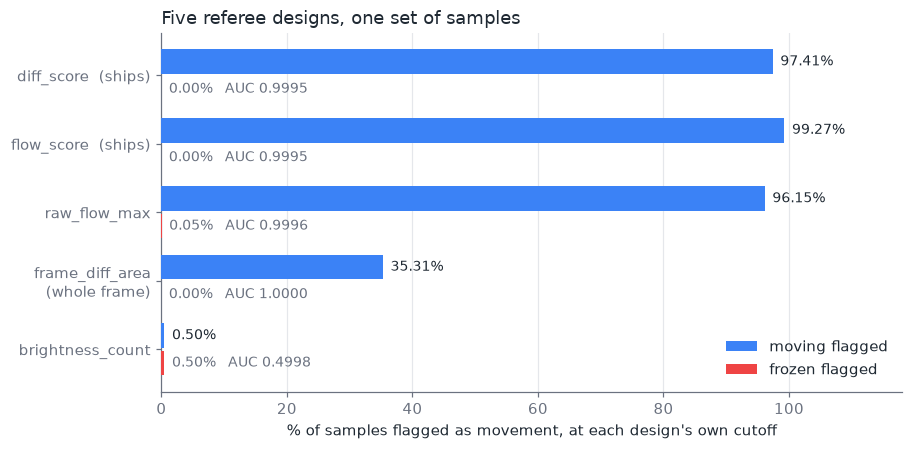

In [2]:
"""Every design, on the same samples: what it catches against what it invents."""

order = ["brightness", "frame_diff_area", "raw_flow", "flow_norm", "diff_norm"]
labels = {
    "brightness": "brightness_count",
    "frame_diff_area": "frame_diff_area\n(whole frame)",
    "raw_flow": "raw_flow_max",
    "flow_norm": "flow_score  (ships)",
    "diff_norm": "diff_score  (ships)",
}

rows = [RESULTS["classifiers"][name] for name in order]
y = np.arange(len(order))
height = 0.36

fig, ax = plt.subplots(figsize=(8.4, 4.2))
ax.barh(y + height / 2 + 0.02, [r["moving_flagged"] for r in rows], height,
        color=MOVING, label="moving flagged", zorder=3)
ax.barh(y - height / 2 - 0.02, [r["frozen_flagged"] for r in rows], height,
        color=FROZEN, label="frozen flagged", zorder=3)

for i, row in enumerate(rows):
    ax.text(row["moving_flagged"] + 1.2, i + height / 2 + 0.02,
            f"{row['moving_flagged']:.2f}%", va="center", fontsize=9, color=INK)
    ax.text(row["frozen_flagged"] + 1.2, i - height / 2 - 0.02,
            f"{row['frozen_flagged']:.2f}%   AUC {row['auc']:.4f}",
            va="center", fontsize=9, color=MUTED)

ax.set_yticks(y, [labels[name] for name in order])
ax.set_xlim(0, 118)
ax.set_xlabel("% of samples flagged as movement, at each design's own cutoff")
ax.set_title("Five referee designs, one set of samples", loc="left", fontsize=12)
ax.xaxis.grid(True, zorder=0)
ax.set_axisbelow(True)
ax.legend(loc="lower right", frameon=False)
plt.tight_layout()
plt.show()

Three things in that chart are worth saying out loud.

**`brightness_count` sits at chance.** Its AUC is 0.4998 and its frozen and
moving flag rates are identical to three decimals — 0.50% against 0.50%.
That is the clearest possible statement that the design has no temporal
term: it never compares two frames, so it cannot tell a held one from a
moving one. What it actually measures is how many pixels a player covers.

**`frame_diff_area` looks perfect here, and its row is not about a player.**
AUC 1.0000, and it takes no box at all — every player in a pair gets the same
whole-frame number. That is a statement about the footage. Its failure needs
a different experiment, further down.

**`raw_flow_max` looks nearly right.** It catches 96.15% of walkers and
almost never fires on a held frame. Its failure is invisible at one
resolution, which is exactly what makes it the interesting one.

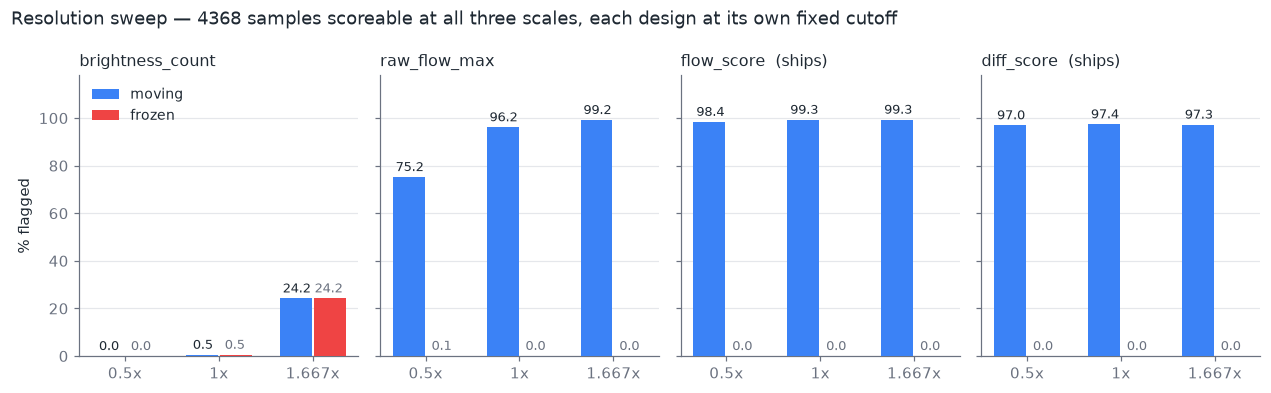

In [3]:
"""The same players, three apparent sizes. Fixed cutoffs, 4368 shared samples."""

sweep = RESULTS["resolution_sweep"]
scales = ["0.5x", "1x", "1.667x"]
panels = [
    ("brightness", "brightness_count"),
    ("raw_flow", "raw_flow_max"),
    ("flow_norm", "flow_score  (ships)"),
    ("diff_norm", "diff_score  (ships)"),
]
x = np.arange(len(scales))
width = 0.34

fig, axes = plt.subplots(1, 4, figsize=(11.6, 3.6), sharey=True)
for ax, (metric, title) in zip(axes, panels):
    moving = [sweep[metric][s]["moving_flagged"] for s in scales]
    frozen = [sweep[metric][s]["frozen_flagged"] for s in scales]
    ax.bar(x - width / 2 - 0.01, moving, width, color=MOVING, label="moving", zorder=3)
    ax.bar(x + width / 2 + 0.01, frozen, width, color=FROZEN, label="frozen", zorder=3)
    for xi, value in zip(x, moving):
        ax.text(xi - width / 2, value + 2.5, f"{value:.1f}", ha="center", fontsize=8.5, color=INK)
    for xi, value in zip(x, frozen):
        ax.text(xi + width / 2, value + 2.5, f"{value:.1f}", ha="center", fontsize=8.5, color=MUTED)
    ax.set_xticks(x, scales)
    ax.set_ylim(0, 118)
    ax.set_title(title, loc="left", fontsize=10.5)
    ax.yaxis.grid(True)
    ax.set_axisbelow(True)

axes[0].set_ylabel("% flagged")
axes[0].legend(frameon=False, fontsize=9, loc="upper left")
fig.suptitle(
    f"Resolution sweep — {sweep['samples']} samples scoreable at all three scales, "
    "each design at its own fixed cutoff",
    x=0.008, ha="left", fontsize=12,
)
plt.tight_layout()
plt.show()

That is where the two unresampled designs give themselves away.

`brightness_count` flags nothing at half size and a quarter of everything at
1.667x — and it flags frozen and moving at the *same* rate at every scale, so
the drift is pure sensitivity to apparent size, not to movement.
`raw_flow_max` loses 21 points of walkers at half size that it catches at
native resolution: the same stride, fewer raw pixels, below a cutoff
expressed in pixels.

The two normalized metrics hold within about a point across a 3.3x span of
apparent size — 11x in pixel area — and never flag a held frame at any scale.

## The idea: measure the player against themselves

A step taken two metres from the camera moves more pixels than the same step
taken ten metres away, and a 4K sensor sees more of them than a 480p one.
Both of those are properties of the camera and the geometry, not of the
player — so both have to divide out before anything is compared to a cutoff.

The judge does it in one move. Every player's box is cropped out of the
grayscale frame and **resampled to a fixed 96 × 96 window** before scoring:

```
w_t        = blur3x3(resize(gray_t[box], 96 × 96))

flow_score = max(percentile(|Farneback(w_{t-1}, w_t)|, 95) - 0.5 px, 0) / 96 / dt
diff_score = count(|w_{t-1} - w_t| > 25) / 9216 / dt
```

The unit is **body-fractions per second**: what fraction of the player's own
apparent size changed, per second of real time. The 95th percentile tracks
the fastest-moving part of a player — a hand, a shifting foot — without
chasing the outliers a flow estimator always produces. The 0.5 px subtraction
is a sub-pixel deadband, because grain jitters flow by a fraction of a pixel
every frame and dividing that by a small `dt` would amplify exactly that
jitter into an elimination.

Below, the same movement is scored at three apparent sizes on a synthetic
scene, where the displacement is known exactly rather than inferred.

In [4]:
"""Live, on a synthetic scene: raw pixels drift with size, body-fractions do not."""

import cv2
from redlight.baselines import raw_flow_max
from redlight.detection import Detection
from redlight.judge import flow_score

WORLD_W, WORLD_H, BASE_W, BASE_H = 1280, 960, 640, 480
BASE_BOX = (160, 80, 160, 320)


def world(cells=(60, 80), seed=7):
    """A deterministic textured canvas: `cells` coarse blocks, smoothed up to world size.

    The block count is the knob that matters. A crop taken at 2x and never
    resampled is four times the pixels, so it needs real local detail at that
    raw size for a flow estimator to have anything to track -- which is why
    the resolution experiment below uses a fine canvas. The frame-rate
    experiment further down uses a coarser one, for a reason stated there.
    """
    rng = np.random.default_rng(seed)
    coarse = rng.integers(0, 256, size=cells).astype(np.uint8)
    return cv2.resize(coarse, (WORLD_W, WORLD_H), interpolation=cv2.INTER_CUBIC)


def render(canvas, scale):
    size = (int(BASE_W * scale), int(BASE_H * scale))
    return cv2.resize(canvas, size, interpolation=cv2.INTER_AREA)


def box_at(scale):
    x, y, w, h = BASE_BOX
    return Detection(int(x * scale), int(y * scale), int(w * scale), int(h * scale))


fine = world((60, 80))
dt, dx_world = 0.1, 20  # 6.0 px of window displacement: inside flow's honest band

print("one stride, three camera distances\n")
print(f"{'scale':>7}  {'box (px)':>12}  {'raw_flow_max':>13}  {'flow_score':>11}")
for scale in (0.5, 1.0, 2.0):
    prev = render(fine, scale)
    cur = render(np.roll(fine, dx_world, axis=1), scale)
    box = box_at(scale)
    raw = raw_flow_max(prev, cur, box)
    norm = flow_score(prev, cur, box, dt)
    print(f"{scale:>6}x  {box.w:>5} x {box.h:<4}  {raw:>13.3f}  {norm:>11.3f}")

one stride, three camera distances

  scale      box (px)   raw_flow_max   flow_score
   0.5x     80 x 160           6.038        0.589
   1.0x    160 x 320          14.994        0.589
   2.0x    320 x 640          58.324        0.589


Same stride, three camera distances. The raw flow magnitude climbs with the
box — nearly ten-fold as the box side quadruples — while the normalized score
sits on the same value to three decimals. That is the entire idea, and
the resolution sweep above is the same claim measured on real footage
instead of a canvas.

## What normalization cannot fix: the clock

Dividing by `dt` looks like it should make any of these frame-rate
independent. It does that for flow, because displacement really is
proportional to elapsed time, so displacement over time is a rate.

It does **not** do it for the changed-pixel count. That count grows faster
than linearly with displacement: a bigger step does not merely move more
pixels, it pushes more of them past the 25-level brightness delta. Halving
the step and halving the interval therefore does not leave the score where
it was.

Here is that measured, on the same synthetic scene — two ways of watching
one real velocity.

one velocity, two sampling intervals

      metric   0.2 s pair   0.1 s pair       gap
  flow_score        0.310        0.260     19.0%
  diff_score        2.081        1.207     72.5%


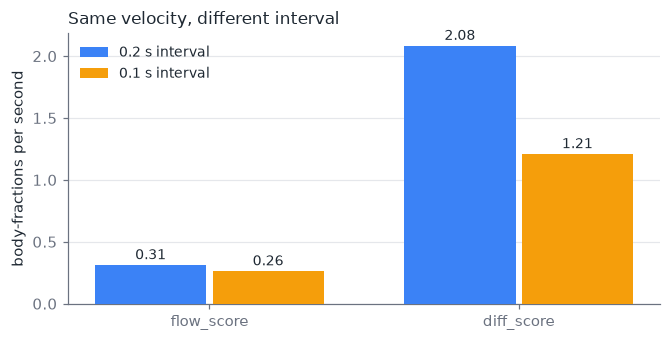

In [5]:
"""The same real velocity, seen at two frame rates. Flow survives; diff does not."""

from redlight.judge import diff_score

# The coarser canvas the characterisation test pins this on. A 20 px step
# across the fine canvas above decorrelates the window outright -- both
# changed-pixel counts saturate and the comparison stops being about dt at
# all, which is its own demonstration that a changed-pixel count is not a
# velocity. This scene keeps the two frames related at both step sizes.
coarse = world((15, 20))
prev = render(coarse, 1.0)


def scored(shift_px, dt):
    cur = render(np.roll(coarse, shift_px, axis=1), 1.0)
    box = box_at(1.0)
    return flow_score(prev, cur, box, dt), diff_score(prev, cur, box, dt)


flow_slow, diff_slow = scored(20, 0.2)   # 20 world px over 0.2 s
flow_fast, diff_fast = scored(10, 0.1)   # 10 world px over 0.1 s -- same velocity

flow_gap = 100 * (flow_slow - flow_fast) / flow_fast
diff_gap = 100 * (diff_slow - diff_fast) / diff_fast

print("one velocity, two sampling intervals\n")
print(f"{'metric':>12}  {'0.2 s pair':>11}  {'0.1 s pair':>11}  {'gap':>8}")
print(f"{'flow_score':>12}  {flow_slow:>11.3f}  {flow_fast:>11.3f}  {flow_gap:>7.1f}%")
print(f"{'diff_score':>12}  {diff_slow:>11.3f}  {diff_fast:>11.3f}  {diff_gap:>7.1f}%")

fig, ax = plt.subplots(figsize=(6.2, 3.2))
x = np.arange(2)
ax.bar(x - 0.19, [flow_slow, diff_slow], 0.36, color=MOVING, label="0.2 s interval", zorder=3)
ax.bar(x + 0.19, [flow_fast, diff_fast], 0.36, color=PICKED, label="0.1 s interval", zorder=3)
for xi, (a, b) in enumerate([(flow_slow, flow_fast), (diff_slow, diff_fast)]):
    ax.text(xi - 0.19, a + 0.05, f"{a:.2f}", ha="center", fontsize=9, color=INK)
    ax.text(xi + 0.19, b + 0.05, f"{b:.2f}", ha="center", fontsize=9, color=INK)
ax.set_xticks(x, ["flow_score", "diff_score"])
ax.set_ylabel("body-fractions per second")
ax.set_title("Same velocity, different interval", loc="left", fontsize=11)
ax.yaxis.grid(True)
ax.set_axisbelow(True)
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

Flow moves by 19% between the two — inside the 30% band the suite pins as
invariance, and that residual is the flow estimator's own noise rather than a
frame-rate effect. The diff score reads about **72% higher** over the longer
interval, for motion that is identical in the world, and no amount of
dividing rescues it: the relationship is not linear to begin with. This is pinned in the suite as a characterisation test
(`test_diff_score_is_not_dt_invariant`) precisely so that nobody reads the
`/ dt` in the formula as a promise of frame-rate independence.

The fix is not arithmetic. It is `FrameSampler`: hold every frame back until
0.1 s of real time has passed since the last released pair, and score only
those pairs. A fast camera then delivers more frames, not different verdicts
— the interval the count is measured over is simply held fixed.

The benchmark plays the same footage on a 10 fps clock and a 30 fps clock
(each frame offered three times) and compares the verdicts over the content
pairs both arms released:

In [6]:
"""Frame-rate sweep: does a faster camera change any call?"""

for metric in ("flow_norm", "diff_norm"):
    arm = RESULTS["fps_sweep"][metric]
    print(f"{metric}")
    print(f"  pairs released      10 fps {arm['10fps']['pairs_released']}"
          f"   |   30 fps {arm['30fps']['pairs_released']}")
    print(f"  pairs compared      {arm['pairs_compared']}"
          f"   (dt mismatch {arm['dt_mismatch_pct']:.2f}%)")
    print(f"  decisions compared  {arm['decisions_compared']}")
    print(f"  decisions agree     {arm['decisions_agree_pct']:.2f}%\n")

flow_norm
  pairs released      10 fps 794   |   30 fps 794
  pairs compared      794   (dt mismatch 0.00%)
  decisions compared  4410
  decisions agree     100.00%

diff_norm
  pairs released      10 fps 794   |   30 fps 794
  pairs compared      794   (dt mismatch 0.00%)
  decisions compared  4410
  decisions agree     100.00%



Every one of 4410 decisions agrees, and the two arms measured every shared
pair over an identical interval. That is what the fixed clock buys, and it is
the reason the browser and the engine can be held to the same cutoff at all.

One detail worth stating rather than smoothing over: the sampler releases the
first frame *at or past* the boundary, so a released interval lands anywhere
in `[0.1 s, 0.1 s + one frame period)` — up to 0.133 s on a 30 fps camera.
Both metrics divide by the `dt` they were actually handed, and the residual
that leaves is what `dt_mismatch_pct` reports.

## Where to put the line

A cutoff nobody can trace is a cutoff nobody can argue with. This one comes
from the two distributions themselves, by one rule:

```
threshold = (frozen_p99 + moving_p1) / 2      when frozen_p99 < moving_p1
```

The frozen class's 99th percentile and the moving class's 1st percentile are
the edges that matter — a cutoff between them clears the noisiest held frame
and still catches all but the faintest walker — and their midpoint is the
point furthest from both. A geometric midpoint was considered and dropped: it
collapses to zero whenever the frozen edge is zero, which is exactly what a
working deadband produces. If the two classes overlap, the harness picks
nothing and says so.

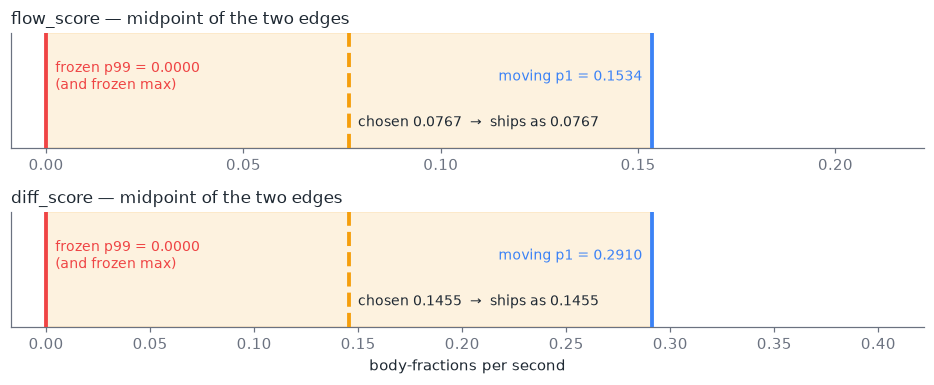

flow: at the chosen cutoff, 0.00% of frozen samples flagged, 99.59% of moving
diff: at the chosen cutoff, 0.00% of frozen samples flagged, 99.52% of moving


In [7]:
"""The corridor each cutoff was picked from, and where it landed."""

fig, axes = plt.subplots(2, 1, figsize=(8.6, 3.6), sharex=False)

for ax, metric, name in zip(axes, ("flow", "diff"), ("flow_score", "diff_score")):
    sep = RESULTS["threshold_separation"][metric]
    chosen = RESULTS["chosen_thresholds"][metric]
    top = sep["moving_p1"] * 1.45

    ax.axvspan(sep["frozen_p99"], sep["moving_p1"], color=PICKED, alpha=0.13, zorder=1)
    ax.axvline(sep["frozen_p99"], color=FROZEN, linewidth=2.5, zorder=3)
    ax.axvline(sep["moving_p1"], color=MOVING, linewidth=2.5, zorder=3)
    ax.axvline(chosen, color=PICKED, linewidth=2.5, linestyle="--", zorder=4)

    ax.annotate(f"frozen p99 = {sep['frozen_p99']:.4f}\n(and frozen max)",
                (sep["frozen_p99"], 0.62), xytext=(6, 0), textcoords="offset points",
                fontsize=9, color=FROZEN, va="center")
    ax.annotate(f"moving p1 = {sep['moving_p1']:.4f}",
                (sep["moving_p1"], 0.62), xytext=(-6, 0), textcoords="offset points",
                fontsize=9, color=MOVING, va="center", ha="right")
    ax.annotate(f"chosen {chosen:.4f}  →  ships as {round(chosen, 4)}",
                (chosen, 0.22), xytext=(6, 0), textcoords="offset points",
                fontsize=9, color=INK, va="center")

    ax.set_xlim(-top * 0.04, top)
    ax.set_ylim(0, 1)
    ax.set_yticks([])
    ax.set_title(f"{name} — {sep['rule']} of the two edges", loc="left", fontsize=11)

axes[-1].set_xlabel("body-fractions per second")
plt.tight_layout()
plt.show()

for metric in ("flow", "diff"):
    applied = RESULTS["threshold_separation"][metric]["applied"]
    print(f"{metric}: at the chosen cutoff, {applied['frozen_flagged']:.2f}% of frozen "
          f"samples flagged, {applied['moving_flagged']:.2f}% of moving")

The corridor is wide because the frozen edge is *exactly* zero on both
metrics — all 4410 held samples score 0.000, frozen max included. Sitting at
the midpoint means the cutoff does not lean toward forgiving the faintest
walker over clearing the noisiest still frame.

It is worth being blunt about what that class is, though: the moving samples
are **pedestrians walking continuously**. Their 1st percentile is not the
faintest motion a real player can make — someone shifting their weight in
front of a webcam scores far below anyone in this footage. So these cutoffs
err strict, which is why the browser ships forgiving (2×) and ruthless (0.6×)
multipliers on top of the measured one rather than pretending one number
suits every room.

The traces below are what a red light actually looks like at that cutoff:
five players walking, three of the same players held still, over one three-
second armed segment.

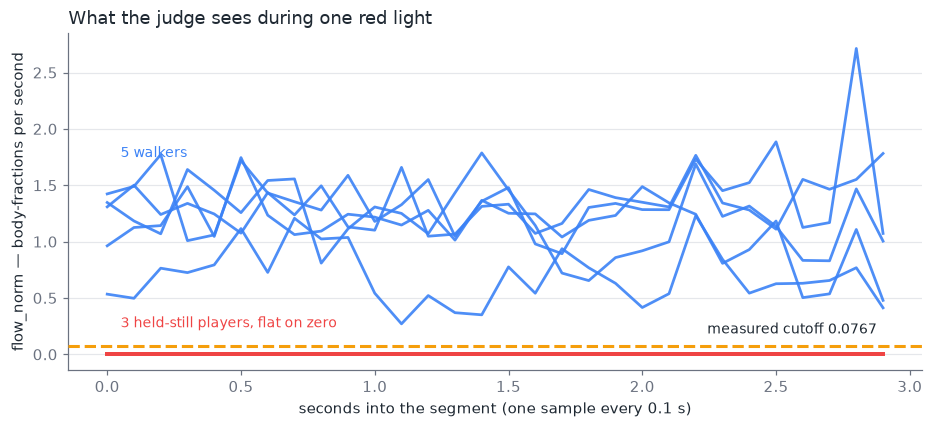

In [8]:
"""One armed segment: five walkers, three held-still players, one cutoff."""

traces = RESULTS["traces"]
chosen = RESULTS["chosen_thresholds"]["flow"]

fig, ax = plt.subplots(figsize=(8.6, 4.0))
for trace in traces["red_phase_player_traces"]:
    moving = trace["kind"] == "moving"
    ax.plot(trace["t"], trace["score"],
            color=MOVING if moving else FROZEN,
            linewidth=1.8 if moving else 2.6,
            alpha=0.9 if moving else 1.0, zorder=3)

ax.axhline(chosen, color=PICKED, linestyle="--", linewidth=2, zorder=4)
ax.annotate(f"measured cutoff {chosen:.4f}", (traces["red_phase_player_traces"][0]["t"][-1], chosen),
            xytext=(-4, 8), textcoords="offset points", ha="right", fontsize=9, color=INK)
ax.annotate("5 walkers", (0.05, 1.75), fontsize=9, color=MOVING)
ax.annotate("3 held-still players, flat on zero", (0.05, 0.24), fontsize=9, color=FROZEN)

ax.set_xlabel(f"seconds into the segment (one sample every {traces['sample_interval_s']} s)")
ax.set_ylabel(f"{traces['metric']} — body-fractions per second")
ax.set_title("What the judge sees during one red light", loc="left", fontsize=12)
ax.yaxis.grid(True)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

## What still fools it

A per-box score is the whole design, and the sharpest way to show what it
buys is to freeze one player into live footage and let the crowd move around
them. The harness does that twice, on the same 230 frames.

In **`isolated`** the frozen crop is drawn over everything, so walkers pass
*behind* the still player. In **`occluded`** the same player is moved to the
busiest spot in the frame and any tracked box crossing theirs is redrawn from
the live frame, so walkers pass *in front of* them.

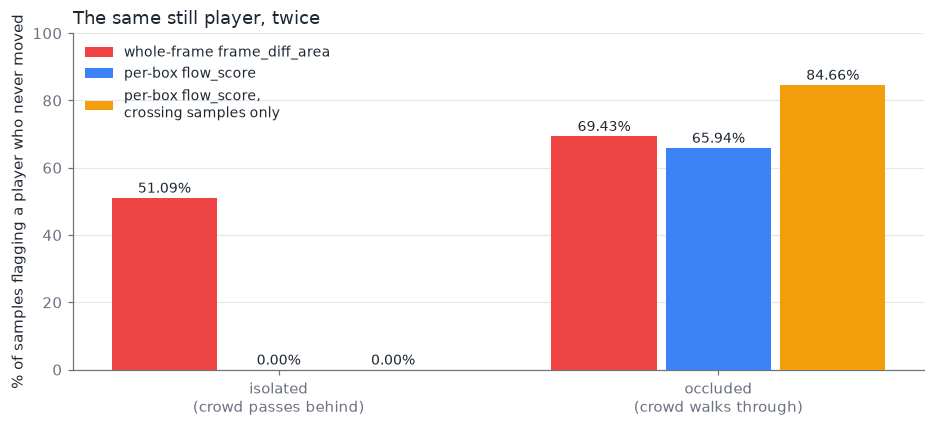

 isolated (crowd passes behind): 40 of 230 frames had somebody crossing the box; whole-frame first false call at 0.8 s
 occluded (crowd walks through): 177 of 230 frames had somebody crossing the box; whole-frame first false call at 0.5 s


In [9]:
"""A motionless player in traffic: what protects them, and what does not."""

bg = RESULTS["background_scenario"]
variants = [("isolated", "crowd passes behind"), ("occluded", "crowd walks through")]
series = [
    ("whole-frame frame_diff_area", "frame_diff_area_flagged_pct", FROZEN),
    ("per-box flow_score", ("per_box_flagged_pct", "flow_norm"), MOVING),
    ("per-box flow_score,\ncrossing samples only", ("per_box_flagged_pct_overlap", "flow_norm"), PICKED),
]

x = np.arange(len(variants))
width = 0.26

fig, ax = plt.subplots(figsize=(8.6, 4.0))
for offset, (label, key, colour) in zip((-width, 0, width), series):
    values = []
    for variant, _ in variants:
        node = bg[variant]
        values.append(node[key] if isinstance(key, str) else node[key[0]][key[1]])
    ax.bar(x + offset, values, width * 0.92, color=colour, label=label, zorder=3)
    for xi, value in zip(x, values):
        ax.text(xi + offset, value + 1.5, f"{value:.2f}%", ha="center", fontsize=9, color=INK)

ax.set_xticks(x, [f"{name}\n({note})" for name, note in variants])
ax.set_ylim(0, 100)
ax.set_ylabel("% of samples flagging a player who never moved")
ax.set_title("The same still player, twice", loc="left", fontsize=12)
ax.yaxis.grid(True)
ax.set_axisbelow(True)
ax.legend(frameon=False, fontsize=9, loc="upper left")
plt.tight_layout()
plt.show()

for variant, note in variants:
    node = bg[variant]
    print(f"{variant:>9} ({note}): {node['overlap_frames']} of {node['frames']} frames had "
          f"somebody crossing the box; whole-frame first false call at "
          f"{node['first_crossing_s']} s")

The left pair is the headline the design was built for. Whole-frame
differencing charges a motionless player for everybody else in the shot — it
crosses its cutoff **0.8 seconds** in and flags **51.09%** of samples — while
the same player scored inside their own box reads **0.00%**, including across
all 39 samples where a walker crossed the box behind them.

The right pair is the limitation, and it is published for the same reason the
rest of this is: scoring a box means scoring whatever is inside it. When a
body walks **through** the box, **84.66%** of the crossing samples flag a
player who never moved. Two things make that a ceiling rather than a precise
figure — the occluder is the walker's bounding box rather than a silhouette,
so it drags some background across with it, and this is raw per-sample
scoring without the smoothing and three-in-a-row confirmation a brief
pass-through may never clear. The direction is not in doubt, only the
magnitude.

The rule that still holds underneath it: a spectator who was not registered
when the countdown opened cannot be eliminated at all, whatever they walk in
front of.

## What the judge ended up being

- **Body-fractions per second.** Crop at the player's box, resample to a
  fixed 96 × 96 window, score the change. Distance and resolution divide out.
- **A fixed 0.1 s sampling clock.** Not a `/ dt` fudge for the diff metric,
  which is superlinear in displacement — the interval is held instead, and
  every one of 4410 verdicts agrees across 10 and 30 fps.
- **A sub-pixel deadband.** 0.5 px on flow, 25 brightness levels on diff, so
  sensor grain is never an elimination.
- **Hysteresis before any call.** An EMA weighted 0.5 on the newest sample,
  then three consecutive samples over the cutoff, plus a 0.6 s grace window
  after the light turns so nobody is punished for a reaction time nobody has.
- **A cutoff read off the data.** The midpoint of frozen p99 and moving p1 —
  0.0767 for flow, 0.1455 for diff — with the corridor, the rule, and the
  applied rates all published.

And what it does not do: it cannot tell a player from somebody walking
through their box, it over-reads very fast motion, and every number above
describes one outdoor courtyard at 10 fps. The next honest measurement is a
second scene, indoors, with a different camera — not a better number on this
one.

The full contracts, formulas and the mutation results that back each claim
are in [`docs/DESIGN.md`](../docs/DESIGN.md).